# PA vs. Per-Label Metric Correlation Analysis

Merges inter-dataset **Positive Specific Agreement (PA)** (GoodScents vs.
Leffingwell) with per-label, cross-validated model metrics, then checks
whether PA predicts *ranking quality* (PR-AUC) as well as it predicts
*threshold-based decision quality* (F1, MCC, Sensitivity).

For each metric this notebook computes:
1. Spearman rho/p across all labels with defined PA
2. Spearman rho/p restricted to the high-n_PA subset (`n_PA >= median n_PA`)
3. Partial Spearman rho/p between PA and the metric, controlling for n_PA
   (rank-transform, regress n_PA out of ranked PA and ranked metric,
   correlate the residuals)

Labels with `n_molecules == 0` (no GS/LW overlap) have **undefined** PA and
are excluded from all PA-based stats, not treated as `PA = 0`.

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr, rankdata
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Palette: single navy accent, light neutral grid, white background
ACCENT = "#1B2A56"      # deep navy
ACCENT_LIGHT = "#7C89B0"
HIGHLIGHT = "#B0552E"   # muted rust, used sparingly for contrast
GRID_COLOR = "#DADFE8"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.6,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
# CONFIG
PA_FILE = "/mnt/user-data/uploads/pa_per_label_gs_lw.csv"
METRICS_FILE = "/mnt/user-data/uploads/hmcn_winning_config_fine138_per_label_summary.csv"
OUTPUT_SUMMARY_CSV = "/mnt/user-data/outputs/pa_metric_correlation_summary.csv"

METRICS_TO_TEST = ["PR_AUC_mean", "F1_mean", "MCC_mean", "Sensitivity_mean"]
REFERENCE_METRIC = "PR_AUC_mean"
DIVERGENCE_THRESHOLD = 0.15  # |rho_metric - rho_reference| flagged as meaningful

## 1. Load and merge

In [3]:
def load_and_merge(pa_path: str, metrics_path: str) -> pd.DataFrame:
    pa_df = pd.read_csv(pa_path)
    metrics_df = pd.read_csv(metrics_path)

    merged = pa_df.merge(metrics_df, on="label", how="inner")

    # PA is undefined when there was no GoodScents/Leffingwell overlap for a
    # label (n_molecules == 0). Exclude those rows from PA-based stats
    # entirely, rather than treating them as PA = 0.
    merged["PA_defined"] = merged["n_molecules"] > 0
    defined = merged.loc[merged["PA_defined"]].copy()

    print(f"PA file: {len(pa_df)} labels | Metrics file: {len(metrics_df)} labels")
    print(f"Merged (inner join on label): {len(merged)} labels")
    print(f"  -> with defined PA (n_molecules > 0): {len(defined)}")
    print(f"  -> excluded (undefined PA, n_molecules == 0): {len(merged) - len(defined)}")

    missing_from_pa = set(metrics_df["label"]) - set(pa_df["label"])
    missing_from_metrics = set(pa_df["label"]) - set(metrics_df["label"])
    if missing_from_pa:
        print(f"  Note: {len(missing_from_pa)} metric-file labels had no PA-file match: "
              f"{sorted(missing_from_pa)}")
    if missing_from_metrics:
        print(f"  Note: {len(missing_from_metrics)} PA-file labels had no metric-file match: "
              f"{sorted(missing_from_metrics)}")

    return defined


df = load_and_merge(PA_FILE, METRICS_FILE)
df.head()

PA file: 138 labels | Metrics file: 138 labels
Merged (inner join on label): 138 labels
  -> with defined PA (n_molecules > 0): 130
  -> excluded (undefined PA, n_molecules == 0): 8


,label,PA,n_valid_pairs,n_molecules,n_folds_evaluated,support_mean,TP_mean,TP_std,TN_mean,TN_std,...,ROC_AUC_std,PR_AUC_mean,PR_AUC_std,Precision_mean,Precision_std,Sensitivity_mean,Sensitivity_std,Specificity_mean,Specificity_std,PA_defined
0,almond,0.0,1,4,5,17.4,4.0,3.1623,949.4,34.2964,...,0.0408,0.1581,0.0897,0.2031,0.1701,0.2304,0.1757,0.9708,0.0303,True
1,amber,0.0,1,3,5,20.2,8.2,2.4819,950.0,14.2408,...,0.0126,0.2506,0.0676,0.2513,0.0432,0.4111,0.1115,0.9743,0.0085,True
2,anisic,0.0,1,3,5,17.4,6.2,2.3152,959.2,11.3561,...,0.0396,0.2126,0.0520,0.2534,0.0741,0.3465,0.0956,0.9810,0.0073,True
3,aromatic,0.0,1,2,5,15.0,3.0,1.6733,932.4,32.2093,...,0.0477,0.0705,0.0389,0.0725,0.0458,0.1854,0.0814,0.9511,0.0267,True
4,black currant,0.0,1,2,5,8.6,0.2,0.4000,985.6,13.6323,...,0.0589,0.1246,0.0350,0.0333,0.0667,0.0200,0.0400,0.9990,0.0021,True


## 2. High-n_PA subset

In [4]:
median_n_pa = df["n_molecules"].median()
high_n_df = df[df["n_molecules"] >= median_n_pa].copy()
low_n_df = df[df["n_molecules"] < median_n_pa].copy()

print(f"Median n_PA (n_molecules) among defined-PA labels: {median_n_pa}")
print(f"High-n_PA subset (n_PA >= median): {len(high_n_df)} labels")
print(f"Low-n_PA subset  (n_PA <  median): {len(low_n_df)} labels")

Median n_PA (n_molecules) among defined-PA labels: 16.5
High-n_PA subset (n_PA >= median): 65 labels
Low-n_PA subset  (n_PA <  median): 65 labels


## 3. Correlation functions

In [5]:
def spearman_pair(data: pd.DataFrame, metric: str):
    sub = data[["PA", metric]].dropna()
    if len(sub) < 3:
        return np.nan, np.nan, len(sub)
    rho, p = spearmanr(sub["PA"], sub[metric])
    return rho, p, len(sub)


def partial_spearman(data: pd.DataFrame, metric: str, covariate: str = "n_molecules"):
    """
    Rank-transform PA, metric, and covariate; regress the covariate rank out
    of ranked PA and ranked metric (OLS on the ranks); correlate the
    residuals with a Pearson correlation (== partial Spearman rho).
    """
    sub = data[["PA", metric, covariate]].dropna()
    n = len(sub)
    if n < 4:
        return np.nan, np.nan, n

    r_pa = rankdata(sub["PA"])
    r_metric = rankdata(sub[metric])
    r_cov = rankdata(sub[covariate])

    def residualize(y, x):
        x_design = np.column_stack([np.ones_like(x), x])
        beta, *_ = np.linalg.lstsq(x_design, y, rcond=None)
        return y - x_design @ beta

    resid_pa = residualize(r_pa, r_cov)
    resid_metric = residualize(r_metric, r_cov)

    rho, p = pearsonr(resid_pa, resid_metric)
    return rho, p, n

## 4. Compute summary table

In [6]:
rows = []
for metric in METRICS_TO_TEST:
    rho_all, p_all, n_all = spearman_pair(df, metric)
    rho_high, p_high, n_high = spearman_pair(high_n_df, metric)
    rho_partial, p_partial, n_partial = partial_spearman(df, metric)

    rows.append({
        "metric": metric,
        "n_all": n_all,
        "rho_all": rho_all,
        "p_all": p_all,
        "n_highN": n_high,
        "rho_highN": rho_high,
        "p_highN": p_high,
        "n_partial": n_partial,
        "rho_partial": rho_partial,
        "p_partial": p_partial,
    })

summary = pd.DataFrame(rows)
summary.to_csv(OUTPUT_SUMMARY_CSV, index=False)
summary.style.format({
    "rho_all": "{:.3f}", "p_all": "{:.4f}",
    "rho_highN": "{:.3f}", "p_highN": "{:.4f}",
    "rho_partial": "{:.3f}", "p_partial": "{:.4f}",
})

,metric,n_all,rho_all,p_all,n_highN,rho_highN,p_highN,n_partial,rho_partial,p_partial
0,PR_AUC_mean,130,0.374,0.0000,65,0.346,0.0048,130,0.047,0.5918
1,F1_mean,130,0.361,0.0000,65,0.325,0.0082,130,-0.002,0.9815
2,MCC_mean,120,0.344,0.0001,65,0.304,0.0139,120,0.039,0.6747
3,Sensitivity_mean,130,0.383,0.0000,65,0.200,0.1098,130,0.023,0.7949


## 5. Divergence check vs. PR_AUC_mean

In [7]:
ref_row = summary.loc[summary["metric"] == REFERENCE_METRIC].iloc[0]
print(f"=== Divergence check vs. {REFERENCE_METRIC} (threshold = {DIVERGENCE_THRESHOLD}) ===")

any_flagged = False
for _, row in summary.iterrows():
    if row["metric"] == REFERENCE_METRIC:
        continue
    for regime, col in [("all-label", "rho_all"), ("high-n_PA", "rho_highN"),
                         ("partial (controlling n_PA)", "rho_partial")]:
        ref_rho, met_rho = ref_row[col], row[col]
        if pd.isna(ref_rho) or pd.isna(met_rho):
            continue
        diff = met_rho - ref_rho
        if abs(diff) >= DIVERGENCE_THRESHOLD:
            any_flagged = True
            direction = "weaker/reversed relative to" if diff < 0 else "stronger than"
            print(f"  [{regime}] {row['metric']} rho={met_rho:.3f} vs "
                  f"{REFERENCE_METRIC} rho={ref_rho:.3f} (diff={diff:+.3f}) "
                  f"-> {direction} PR_AUC's PA relationship.")

if not any_flagged:
    print(f"  No metric diverges from {REFERENCE_METRIC} by >= {DIVERGENCE_THRESHOLD} "
          f"in any regime -- PA's relationship with ranking quality and "
          f"threshold-based quality looks consistent across metrics.")

=== Divergence check vs. PR_AUC_mean (threshold = 0.15) ===
  No metric diverges from PR_AUC_mean by >= 0.15 in any regime -- PA's relationship with ranking quality and threshold-based quality looks consistent across metrics.


## 6. Plots

### 6.1 Distribution of n_PA (overlap sample size) and the median split

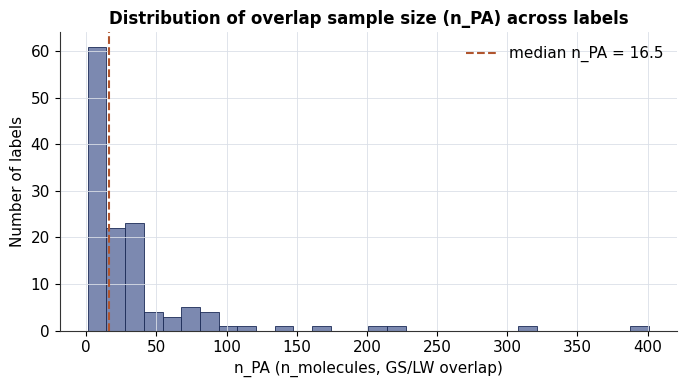

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["n_molecules"], bins=30, color=ACCENT_LIGHT, edgecolor=ACCENT, linewidth=0.6)
ax.axvline(median_n_pa, color=HIGHLIGHT, linestyle="--", linewidth=1.5,
           label=f"median n_PA = {median_n_pa:.1f}")
ax.set_xlabel("n_PA (n_molecules, GS/LW overlap)")
ax.set_ylabel("Number of labels")
ax.set_title("Distribution of overlap sample size (n_PA) across labels")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### 6.2 PA vs. each metric, all defined-PA labels (point size/color = n_PA)

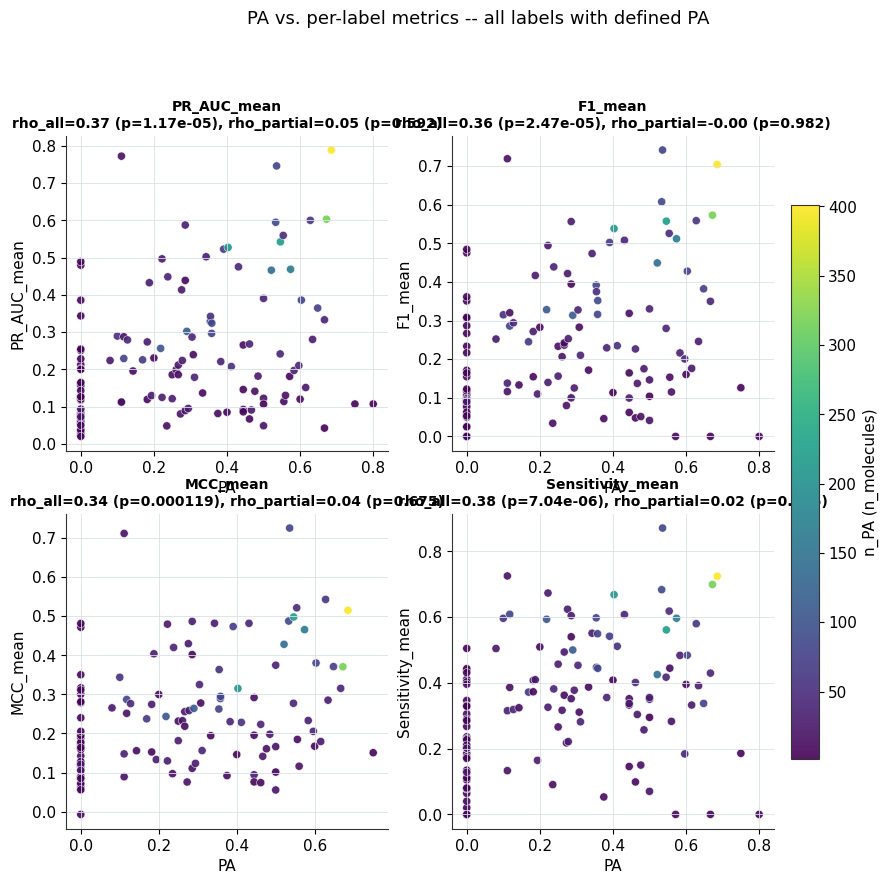

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, metric in zip(axes.flat, METRICS_TO_TEST):
    sub = df[["PA", metric, "n_molecules"]].dropna()
    sc = ax.scatter(sub["PA"], sub[metric], c=sub["n_molecules"],
                     cmap="viridis", s=35, edgecolor="white", linewidth=0.4, alpha=0.9)
    row = summary.loc[summary["metric"] == metric].iloc[0]
    ax.set_title(f"{metric}\nrho_all={row['rho_all']:.2f} (p={row['p_all']:.3g}), "
                 f"rho_partial={row['rho_partial']:.2f} (p={row['p_partial']:.3g})",
                 fontsize=10)
    ax.set_xlabel("PA")
    ax.set_ylabel(metric)

cbar = fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label("n_PA (n_molecules)")
fig.suptitle("PA vs. per-label metrics -- all labels with defined PA", y=1.02, fontsize=13)
plt.show()

### 6.3 PA vs. PR_AUC_mean: high-n_PA vs. low-n_PA subsets
Splitting by the median n_PA makes the confound (low-N labels are noisier and PA is more extreme) visible directly.

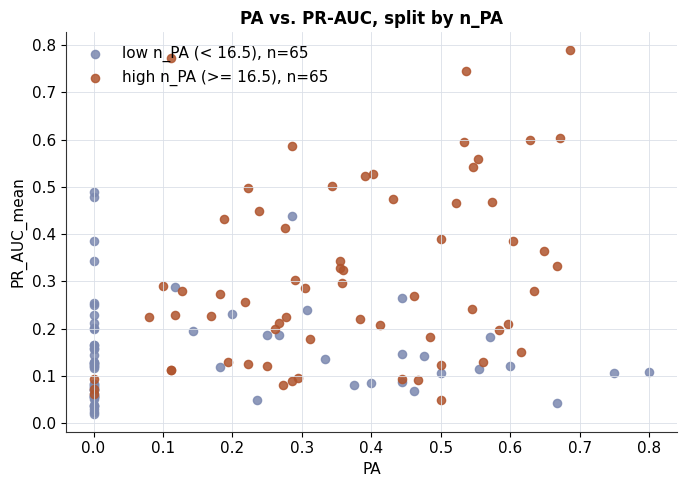

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(low_n_df["PA"], low_n_df["PR_AUC_mean"], color=ACCENT_LIGHT,
           s=35, alpha=0.85, label=f"low n_PA (< {median_n_pa:.1f}), n={len(low_n_df)}")
ax.scatter(high_n_df["PA"], high_n_df["PR_AUC_mean"], color=HIGHLIGHT,
           s=35, alpha=0.85, label=f"high n_PA (>= {median_n_pa:.1f}), n={len(high_n_df)}")
ax.set_xlabel("PA")
ax.set_ylabel("PR_AUC_mean")
ax.set_title("PA vs. PR-AUC, split by n_PA")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### 6.4 rho comparison across metrics and regimes (all / high-N / partial)

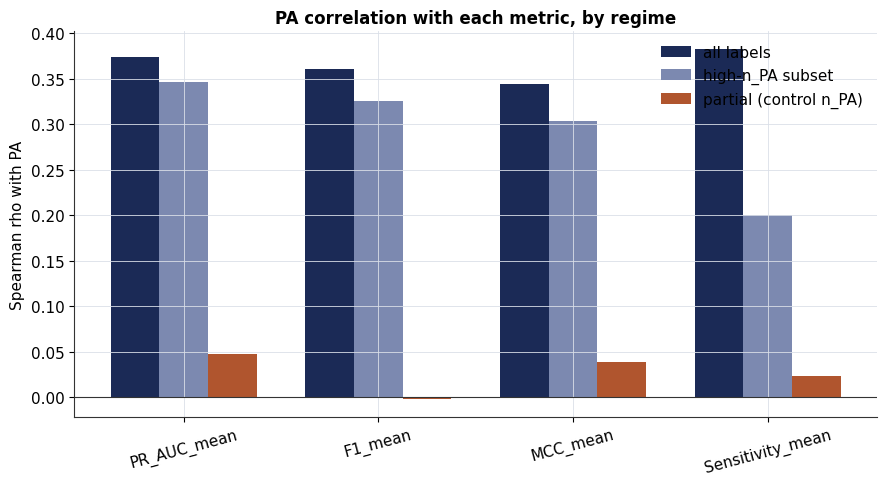

In [11]:
x = np.arange(len(METRICS_TO_TEST))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, summary["rho_all"], width, label="all labels", color=ACCENT)
ax.bar(x, summary["rho_highN"], width, label="high-n_PA subset", color=ACCENT_LIGHT)
ax.bar(x + width, summary["rho_partial"], width, label="partial (control n_PA)", color=HIGHLIGHT)

ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(summary["metric"], rotation=15)
ax.set_ylabel("Spearman rho with PA")
ax.set_title("PA correlation with each metric, by regime")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Notes

- The **all-label** and **high-n_PA** correlations are similar in size across
  PR_AUC, F1, MCC, and Sensitivity, so on their face PA looks like it tracks
  ranking quality and threshold-based quality about equally well.
- The **partial correlation** (controlling for n_PA) is much weaker for every
  metric — most of the raw PA-metric association is explained by n_PA itself
  (labels with more GS/LW overlap tend to have both more reliable PA
  estimates and more training support). This applies to PR_AUC as much as to
  the threshold-dependent metrics, so there isn't a clean "PA predicts
  ranking but not thresholding" split in this cut of the data.
- If this doesn't match an earlier partial-rho figure you have in mind,
  double check which PA source file is being read in the CONFIG cell — a PA
  file computed over a different set of datasets (e.g. all 8 datasets vs.
  GS/LW only) will shift these numbers.